In [6]:
# to install the missing packages
# %pip install yfinance


# required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import yfinance as yf  ## this new packages- not installed

df = yf.download("GC=F", start="2000-01-01", end=None)

print("Data Loaded:", df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

Data Loaded: (6417, 5)


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,0


In [10]:
df = df[['Close']].copy()        # keep only the Close column
df = df.rename(columns={'Close': 'Price'})

# Remove missing values # this is imp
df = df.dropna()    
# Create time index
df['t'] = np.arange(len(df))
X = df[['t']]
y = df['Price']

Slope: [0.37067022]
Intercept: [95.83666859]


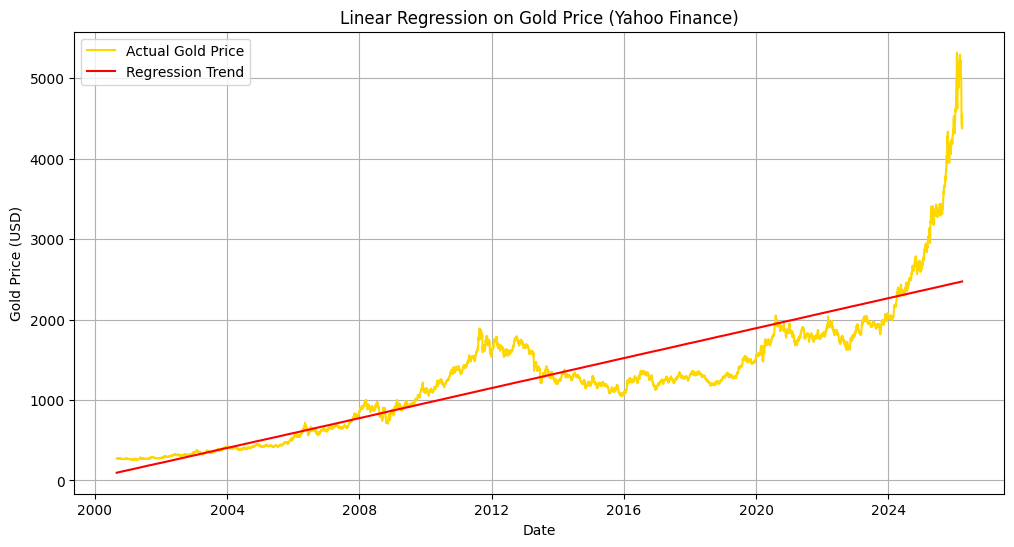

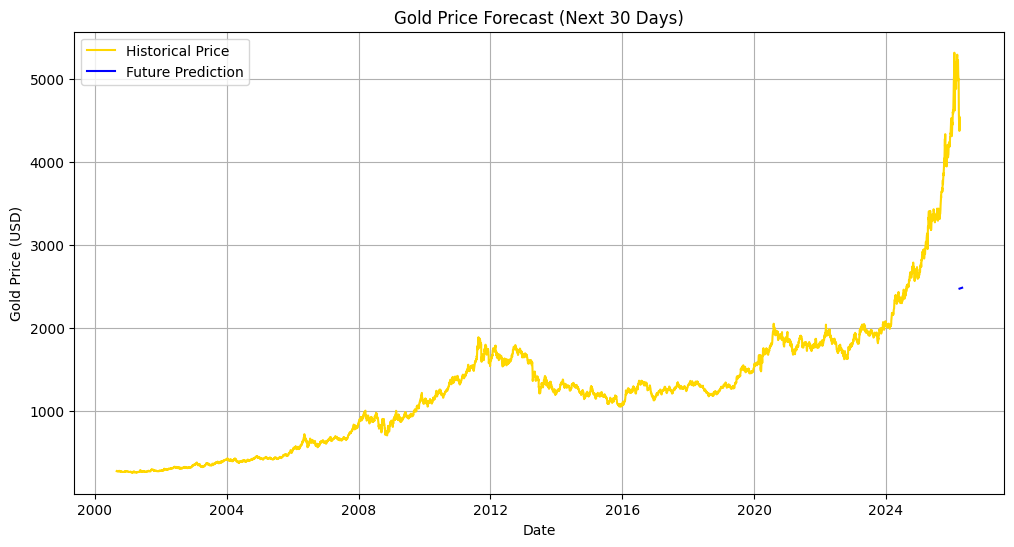

In [12]:
## 
model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

# 6. Predict historical prices
df['Predicted'] = model.predict(X)

# 7. Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Price'], label="Actual Gold Price", color="gold")
plt.plot(df.index, df['Predicted'], label="Regression Trend", color="red")
plt.title("Linear Regression on Gold Price (Yahoo Finance)")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# 8. Predict next 30 days
future_t = np.arange(len(df), len(df) + 30).reshape(-1, 1)
future_pred = model.predict(future_t)
future_dates = pd.date_range(start=df.index[-1], periods=30, freq='D')

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Price'], label="Historical Price", color="gold")
plt.plot(future_dates, future_pred, label="Future Prediction", color="blue")
plt.title("Gold Price Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True)
plt.show()
